In [66]:
from sklearn.datasets import make_regression
import pandas as pd 
import numpy as np

In [67]:
x, y = make_regression(n_samples = 4 , n_targets = 1 , n_features = 1, n_informative = 1, noise = 80,random_state = 13)

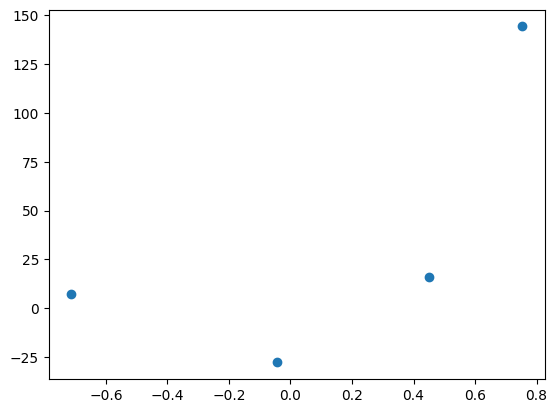

In [68]:
import matplotlib.pyplot as plt 
plt.scatter(x, y)

applying ols on the above data 

In [69]:
from sklearn.linear_model import LinearRegression

In [70]:
lr= LinearRegression()
lr.fit(x , y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78.35]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.16
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1.11]


In [71]:
lr.coef_

array([78.35063668])

In [ ]:
lr.intercept_ #b

np.float64(26.15963284313262)

plot of the LR

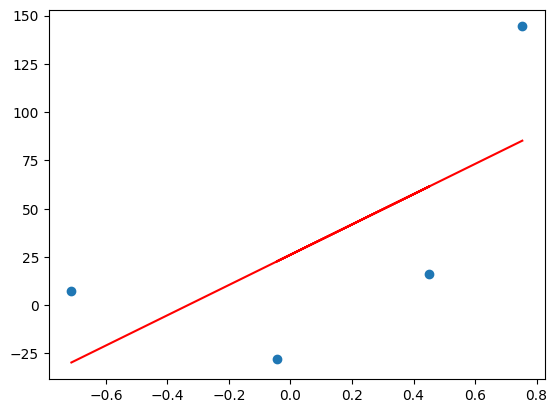

In [73]:
plt.scatter(x ,y)
plt.plot( x,lr.predict(x) , color = 'red')

lets apply gradient descent assuming slope is constant  m = 78.35
also let b = 0, slowly through gradient descent , we will approach the correct value 26.15 . y_pred = ((78.35 * x) + 0).reshape(4)

In [74]:
y_pred = ((x*78.35)+ 0 ).reshape(4)
m = 78.35

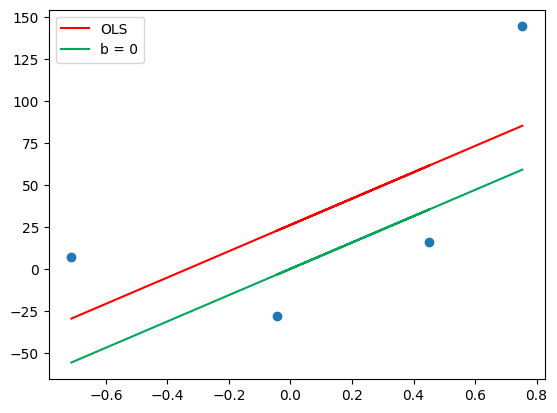

In [75]:
plt.scatter(x, y)
plt.plot(x, lr.predict(x) , color = 'red', label = 'OLS')
plt.plot(x , y_pred , color = '#00a65a', label = 'b = 0')
plt.legend()
plt.show()



ravel() returns a view of the original array whenever possible, not a copy. That means if you modify the raveled array,flatten(), which does the same flattening but always returns a copy — safer if you don't want to accidentally mutate the original array.

In [76]:
m = 78.35
b = 0 
#learning rate *slope = step_size 
#dJ/db= 0
loss_slope = -2 * np.sum(y -m*x.ravel() - b )
loss_slope

np.float64(-209.27763408209216)

In [77]:
#let the learning rate lr be 0.1
LR = 0.1
step_size = loss_slope * LR
step_size

np.float64(-20.927763408209216)

In [78]:
#calculating the new intercept 

b = b- step_size
b

np.float64(20.927763408209216)

In [79]:
y_pred1 = ((78.35*x)+b).reshape(4)

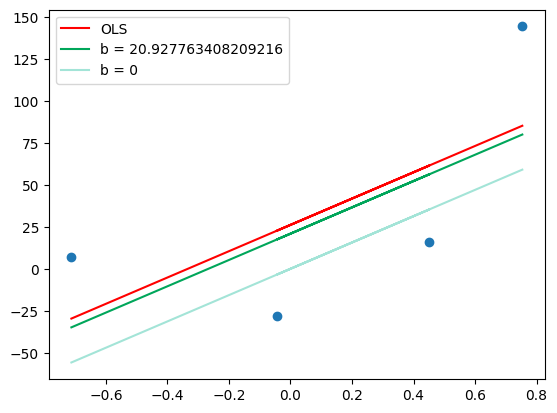

In [80]:
plt.scatter(x, y)
plt.plot(x, lr.predict(x) , color = 'red', label = 'OLS')
plt.plot(x , y_pred1 , color = '#00a65a', label = 'b = {}'.format(b))
plt.plot(x , y_pred , color = '#A3E4D7', label = 'b = 0' )
plt.legend()
plt.show()



In [81]:
#iteration 2 
loss_slope = - 2* np.sum(y - m* x.ravel() - b )
loss_slope 
#aimed loss slope = 0

np.float64(-41.85552681641845)

In [82]:
step_size = LR * loss_slope 
step_size 

np.float64(-4.185552681641845)

In [83]:
b = b - step_size
b 

np.float64(25.11331608985106)

In [84]:
y_pred2 = ((78.35*x)+b).reshape(4)

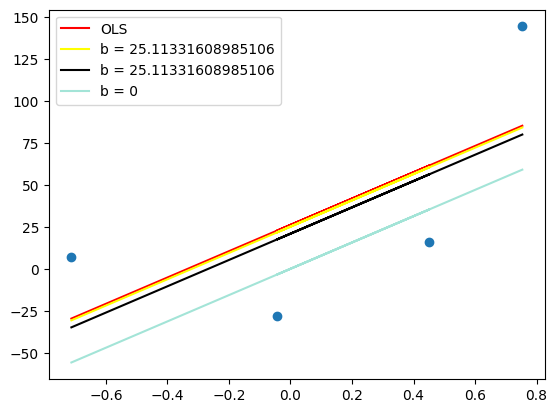

In [85]:
plt.scatter(x, y)
plt.plot(x, lr.predict(x) , color = 'red', label = 'OLS')
plt.plot(x , y_pred2 , color = 'yellow', label = 'b = {}'.format(b))
plt.plot(x , y_pred1 , color = 'black', label = 'b = {}'.format(b))
plt.plot(x , y_pred , color = '#A3E4D7', label = 'b = 0' )
plt.legend()
plt.show()

In [86]:
#iteration 3 

loss_slope = -2 * np.sum(y - m * x.ravel()-b )
loss_slope

np.float64(-8.37110536328369)

In [87]:
step_size = loss_slope * LR
step_size

np.float64(-0.837110536328369)

In [88]:
b = b - step_size 
b

np.float64(25.95042662617943)

In [89]:
y_pred3 = ((78.35*x)+b).reshape(4)

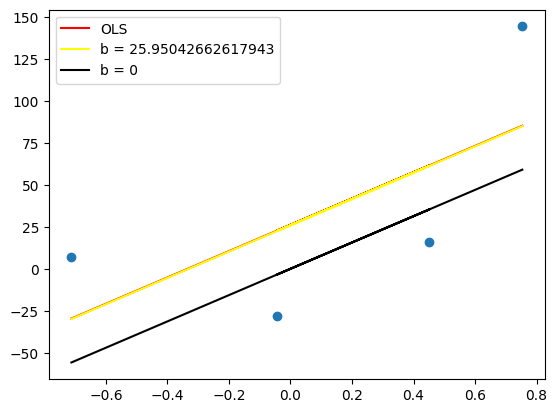

In [90]:
plt.scatter(x, y)
plt.plot(x, lr.predict(x) , color = 'red', label = 'OLS')
plt.plot(x , y_pred3 , color = 'yellow', label = 'b = {}'.format(b))
#plt.plot(x , y_pred2 , color = 'green', label = 'b = {}'.format(b))
#plt.plot(x , y_pred1 , color = 'black', label = 'b = {}'.format(b))
plt.plot(x , y_pred , color = 'black', label = 'b = 0' )
plt.legend()
plt.show()

In [91]:
loss_slope = -2*np.sum(y-m*x.ravel() -b)
loss_slope

np.float64(-1.6742210726567492)

In [92]:
step_size = LR*loss_slope 
step_size


np.float64(-0.16742210726567494)

In [93]:
b = b-step_size
b

np.float64(26.117848733445104)

In [94]:
y_pred4 = ((78.35*x)+b).reshape(4)

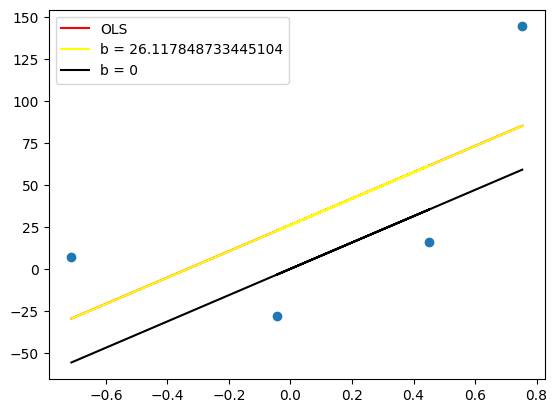

In [95]:
plt.scatter(x, y)
plt.plot(x, lr.predict(x) , color = 'red', label = 'OLS')
plt.plot(x , y_pred4 , color = 'yellow', label = 'b = {}'.format(b))
#plt.plot(x , y_pred2 , color = 'green', label = 'b = {}'.format(b))
#plt.plot(x , y_pred1 , color = 'black', label = 'b = {}'.format(b))
plt.plot(x , y_pred , color = 'black', label = 'b = 0' )
plt.legend()
plt.show()

In [96]:
loss_slope = -2*np.sum(y-m*x.ravel() -b)
loss_slope

np.float64(-0.33484421453132995)

In [ ]:
#on repeating a fe more times , we will get the right answer.

In [97]:
step_size = LR* loss_slope
loss_slope

np.float64(-0.33484421453132995)

In [ ]:
b = b- step_size #very close to the og b .
b

np.float64(26.151333154898236)

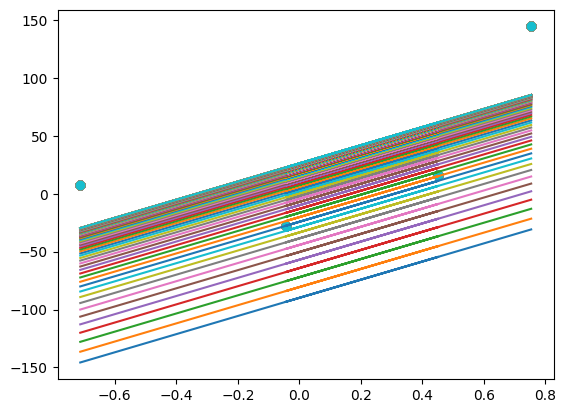

In [104]:
#doing the same thing using the loop

m = 78.35
b = -100 
LR = 0.01

epochs = 100

for i in range(epochs) :
    loss_slope = -2 * np.sum(y - m*x.ravel() - b)
    step_size = LR * loss_slope
    b = b - step_size 

    y_pred = m* x + b 

    plt.plot(x , y_pred)

    plt.scatter(x, y )